# 02 — One Neuron, Tensor Math, Weights, Bias, and Activation (TensorFlow / Keras)

A neuron performs two conceptually separate operations:

$$
z = \sum_i w_i x_i + b = \mathbf{w}^T\mathbf{x}+b
$$

followed by

$$
a=\phi(z).
$$

The first part is **affine geometry**. The second part introduces **nonlinearity**. Keeping these ideas separate is essential for understanding deep networks.

### Meaning of each symbol

| Symbol | Technical meaning | Practical interpretation |
|---|---|---|
| $x_i$ | input feature | pixel intensity or learned feature |
| $w_i$ | trainable coefficient | how strongly that feature affects this neuron |
| $b$ | trainable offset | shifts the neuron's response threshold |
| $z$ | pre-activation | raw evidence before nonlinearity |
| $a$ | activation | signal forwarded to the next layer |


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)

import tensorflow as tf
tf.random.set_seed(SEED)
print('tensorflow version:', tf.__version__)


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)


2026-09-07 12:01:01.202143: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-07 12:01:01.228604: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow version: 2.18.0


## Read the next code line-by-line

- `x` is the input vector.
- `w` has exactly one coefficient per input element.
- `x * w` exposes the **individual additive contribution** of each feature.
- summing those contributions implements the dot product.
- adding `b` shifts the affine response.
- ReLU computes `max(0, z)` and determines what signal survives.


In [2]:
import tensorflow as tf
x = tf.constant([0.0, 0.3, 0.9, 0.2], dtype=tf.float32)
w = tf.constant([0.4, -0.7, 0.8, 0.1], dtype=tf.float32)
b = tf.constant(0.05)
products = x * w
z = tf.reduce_sum(products) + b
a = tf.nn.relu(z)
print('x*w:', products.numpy())
print('sum(x*w):', float(tf.reduce_sum(products)))
print('z = sum(x*w)+b:', float(z))
print('ReLU(z):', float(a))


x*w: [ 0.         -0.21000001  0.71999997  0.02      ]
sum(x*w): 0.5299999713897705
z = sum(x*w)+b: 0.5799999833106995
ReLU(z): 0.5799999833106995


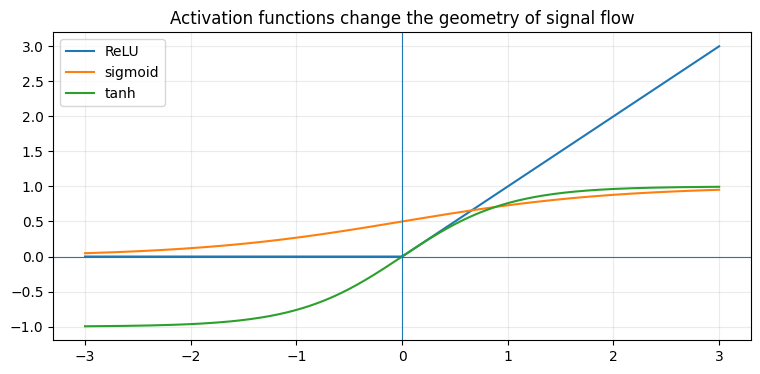

In [3]:
vals = np.linspace(-3, 3, 300)
relu = np.maximum(0, vals)
sigmoid = 1/(1+np.exp(-vals))
tanh = np.tanh(vals)
plt.figure(figsize=(9,4))
plt.plot(vals, relu, label='ReLU')
plt.plot(vals, sigmoid, label='sigmoid')
plt.plot(vals, tanh, label='tanh')
plt.axhline(0, linewidth=.8); plt.axvline(0, linewidth=.8)
plt.legend(); plt.grid(alpha=.25); plt.title('Activation functions change the geometry of signal flow'); plt.show()


## What affects what?

Changing an input changes only the terms connected to that input. Changing a weight changes how strongly one feature contributes. Changing the bias moves the neuron's response globally. Changing the activation changes the shape of the mapping itself and therefore changes gradient flow during training.
